OOD Evaluation using TorchUncertainty
====================

In this tutorial, we demonstrate out-of-distribution (OOD) evaluation with TorchUncertainty
datamodules and routines. You will learn to:

1. **Set up a CIFAR-100 datamodule** with in-distribution, near-OOD, and far-OOD splits.
2. **Run `ClassificationRoutine`** to report in-distribution accuracy and OOD metrics (AUROC, AUPR, FPR95).
3. **Plug in custom OOD datasets** for fully custom evaluation.

## Foreword on out-of-distribution detection

OOD detection measures how well a model recognizes inputs outside its training distribution.
TorchUncertainty integrates common OOD metrics in the Lightning test loop:

- **AUROC** — area under the ROC curve
- **AUPR** — area under the precision–recall curve
- **FPR95** — false positive rate at 95% true positive rate

By default, near and far OOD splits follow the
[OpenOOD](https://arxiv.org/pdf/2306.09301) benchmark. You can override them with
`near_ood_datasets` and `far_ood_datasets` on the datamodule.

## Supported datamodules and default OOD splits

| Datamodule | In-domain | Default near-OOD (hard) | Default far-OOD (easy) |
| --- | --- | --- | --- |
| `CIFAR10DataModule` | CIFAR-10 | CIFAR-100, Tiny ImageNet | MNIST, SVHN, Textures, Places365 |
| `CIFAR100DataModule` | CIFAR-100 | CIFAR-10, Tiny ImageNet | MNIST, SVHN, Textures, Places365 |
| `ImageNetDataModule` | ImageNet-1K | SSB-hard, NINCO | iNaturalist, Textures, OpenImage-O |
| `ImageNet200DataModule` | ImageNet-200 | SSB-hard, NINCO | iNaturalist, Textures, OpenImage-O |

## Some Supported OOD criteria

| Criterion | Reference |
| --- | --- |
| `msp` | Hendrycks & Gimpel — [ICLR Workshop 2017](https://arxiv.org/abs/1610.02136) |
| `maxlogit` | — |
| `energy` | Liu et al. — [NeurIPS 2020](https://arxiv.org/abs/2010.03759) |
| `odin` | Liang, Li & Srikant — [ICML 2018](https://arxiv.org/abs/1706.02690) |
| `entropy` | — |
| `mutual_information` | — |
| `variation_ratio` | — |
| `scale` | Hendrycks et al. — [ICML 2022](https://proceedings.mlr.press/v162/hendrycks22a/hendrycks22a.pdf) |
| `ash` | Djurisic et al. (ASH) — [ICLR 2023](https://arxiv.org/pdf/2209.09858) |
| `react` | Sun et al. — [NeurIPS 2021](https://proceedings.neurips.cc/paper/2021/file/01894d6f048493d2cacde3c579c315a3-Paper.pdf) |
| `adascale_a` | Regmi et al. — [arXiv 2025](https://arxiv.org/pdf/2503.08023) |
| `vim` | Wang et al. — [CVPR 2022](https://openaccess.thecvf.com/content/CVPR2022/papers/Wang_ViM_Out-of-Distribution_With_Virtual-Logit_Matching_CVPR_2022_paper.pdf) |
| `knn` | Sun et al. — [ICML 2022](https://arxiv.org/abs/2106.01477) |
| `gen` | Liu et al. — [CVPR 2023](https://openaccess.thecvf.com/content/CVPR2023/papers/Liu_GEN_Pushing_the_Limits_of_Softmax-Based_Out-of-Distribution_Detection_CVPR_2023_paper.pdf) |
| `nnguide` | Park et al. — [ICCV 2023](https://openaccess.thecvf.com/content/ICCV2023/papers/Park_Nearest_Neighbor_Guidance_for_Out-of-Distribution_Detection_ICCV_2023_paper.pdf) |
| `neco` | Ammar et al. — [ICLR 2024](https://arxiv.org/abs/2310.06823) |

> **Note:** Pass any criterion as `ood_criterion` to `ClassificationRoutine`.

> **Note:** **Near-OOD** splits are semantically close to the in-domain data; **far-OOD** splits
> are more distant. Override defaults with
> `near_ood_datasets` / `far_ood_datasets`.


## 1. Setup

Setup dependencies and necessary plotting utils

In [8]:
!pip install git+https://github.com/torch-uncertainty/torch-uncertainty.git@OodEval

  Cloning https://github.com/torch-uncertainty/torch-uncertainty.git (to revision OodEval) to /tmp/pip-req-build-4c6g22f2
  Running command git clone --filter=blob:none --quiet https://github.com/torch-uncertainty/torch-uncertainty.git /tmp/pip-req-build-4c6g22f2
  Running command git checkout -b OodEval --track origin/OodEval
  Switched to a new branch 'OodEval'
  Branch 'OodEval' set up to track remote branch 'OodEval' from 'origin'.
  Resolved https://github.com/torch-uncertainty/torch-uncertainty.git to commit a4d37151fed0a9218b69c8b4d750dd67323f5b39
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for torch_uncertainty: filename=torch_uncertainty-0.7.0.post1-py3-none-any.whl size=397846 sha256=575522797476b9c43ca7613edfb404e57544f63f518eade0d74134466d0b8244
  Stored in directory: /tmp/pip-ephem-wheel-cache-ua31hdt9/wheels/2a/eb/e3/817f1f0c4a8cd1f1dec9d52903b2bda1c2754dfdbf3189d991

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch


def plot_ood_histograms(
    routine,
    tag: str,
    out_dir: Path = Path("figures/ood_tutorial"),
    *,
    show: bool = True,
    save: bool = True,
    bins: int = 20,
):
    id_scores = torch.cat(routine.id_score_storage).numpy().ravel()
    panels = [
        (name, torch.cat(batches).numpy().ravel())
        for name, batches in routine.ood_score_storage.items()
        if batches
    ]
    if not panels:
        print("No OOD score buffers to plot.")
        return

    plt.close("all")
    n= len(panels)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.6 * nrows), squeeze=False)
    fig.suptitle(f"ID vs OOD scores — {tag}", fontsize=13)

    for ax, (name, ood) in zip(axes.flat, panels, strict=False):
        for arr, label, color, edge in (
            (id_scores, "In-distribution", "#1f77b4", "#0d559f"),
            (ood, "Out-of-distribution", "#ff7f0e", "#d45f00"),
        ):
            ax.hist(arr, bins=bins, density=True, alpha=0.45, linewidth=0.8,
                    label=label, color=color, edgecolor=edge)
        ax.set(title=name, xlabel="Score", ylabel="Density")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(fontsize=8)
    for ax in axes.flat[n:]:
        ax.set_visible(False)

    fig.tight_layout()
    out_dir.mkdir(parents=True, exist_ok=True)
    if save:
        path = out_dir / f"hist_grid_{tag}.png"
        fig.savefig(path, dpi=120, bbox_inches="tight")
        print(f"Saved {path}")
    if show:
        try:
            from IPython.display import display
            display(fig)
        except ImportError:
            plt.show()
    plt.close(fig)

## 2. Load the trained model
In this tutorial we will be loading a pretrained model, but you can also train your own using the same classification routine and still get ood related metrics at test phase.


In [2]:
from huggingface_hub import hf_hub_download

from torch_uncertainty.models.classification import resnet

net = resnet(in_channels=3, arch=18, num_classes=100, style="cifar", conv_bias=False)

# load the model
path = hf_hub_download(repo_id="torch-uncertainty/resnet18_c100", filename="resnet18_c100.ckpt")
net.load_state_dict(torch.load(path))

net.cuda()
net.eval()


/home/themis/miniconda3/envs/test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


_ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (optional_pool): Identity()
  (layer1): Sequential(
    (0): _BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout2d(p=0.0, inplace=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): _BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout2d(p=0.0, inplace=False)
      (conv2): Conv2d(6

## 3. Defining the necessary datamodules
We instantiate our trainer (mainly used for testing in this tutorial) and define the root of the datasets and the logs.
We also create the datamodule that handles the cifar100 dataset, dataloaders and transforms.
Datamodules can also handle OOD detection by setting the eval_ood parameter to True.


In [3]:
import torch.nn as nn
from lightning.pytorch.loggers import TensorBoardLogger

from torch_uncertainty import TUTrainer
from torch_uncertainty.datamodules import CIFAR100DataModule
from torch_uncertainty.routines import ClassificationRoutine

root = Path("data1")

datamodule = CIFAR100DataModule(root=root, batch_size=200, eval_ood=True, eval_shift=True)

trainer = TUTrainer(
    accelerator="gpu",
    enable_progress_bar=True,
    devices=1,
    logger=TensorBoardLogger(save_dir="logs/ood_tutorial", name="run"),
)


Asdfghjkl backend not available since the old asdfghjkl dependency is not installed. If you want to use it, run: pip install git+https://git@github.com/wiseodd/asdl@asdfghjkl
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## 4. Define the classification routine and launch the test
For our target task here being classification we use ClassificationRoutine from TorchUncertainty 
The routine is configured to handle OOD detection and distributional shifts using the specified model, loss function, and evaluation criteria.


In [4]:
#MSP as criterion
routine = ClassificationRoutine(
    num_classes=datamodule.num_classes,
    eval_ood=True,
    model=net,
    loss=nn.CrossEntropyLoss(),
    eval_shift=True,
    ood_criterion="msp",
    log_plots=True,
)

# Perform testing using the defined routine and datamodule.
results = trainer.test(model=routine, datamodule=datamodule)

/home/themis/miniconda3/envs/test/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `FPR95` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
You are using a CUDA device ('NVIDIA RTX 6000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Files already downloaded and verified
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/themis/miniconda3/envs/test/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4

Testing DataLoader 9: 100%|██████████| 950/950 [00:19<00:00, 49.87it/s]


┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃      Classification       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     Acc      │          74.750%          │
│    Brier     │          0.36506          │
│   Entropy    │          0.53935          │
│     NLL      │          1.02712          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃        Calibration        ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     ECE      │          9.477%           │
│     aECE     │          9.477%           │
└──────────────┴───────────────────────────┘
                           OOD Results                           
┏━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┓
┃     Dataset      │    AUROC     │    FPR95     │     AUPR     ┃
┠──────────────────┼──────────────┼──────────────┼──────────────┨
┃     cifar10      │   76.566%    │   61.660%    │   72.140%    ┃
┃   tinyimagenet   │   79.448%    │   54.050%    │   66.917%    ┃
┃ NearOOD Average  │   78.007%    │   57.855%    │   69.528%    ┃
┃      mnist       │   72.673%    │   65.320%    │   93.413%    ┃
┃       svhn       │   78.585%    │   57.370%    │   88.034%    ┃
┃     texture      │   74.605%    │   68.950%    │   58.083%    ┃
┃    places365     │   77.341%    │   59.510%    │   89.938%    ┃
┃  FarOOD Average  │   75.801%    │   62.788%    │   82.367%    ┃
┗━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┛
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃ Selective Classification  ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    AUGRC     │          5.702%           │
│     AURC     │          7.389%           │
│  Cov@5Risk   │          53.320%          │
│  Risk@80Cov  │          15.050%          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃  Distribution Shift lvl1  ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    AUGRC     │          10.956%          │
│     AURC     │          15.212%          │
│     Acc      │          62.207%          │
│    Brier     │          0.54208          │
│  Cov@5Risk   │           nan%            │
│     ECE      │          15.674%          │
│     NLL      │          1.75462          │
│  Risk@80Cov  │          27.999%          │
│     aECE     │          15.668%          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃        Complexity         ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    flops     │         222.19 G          │
│    params    │          11.22 M          │
└──────────────┴───────────────────────────┘

Saved figures/ood_tutorial/hist_grid_msp.png


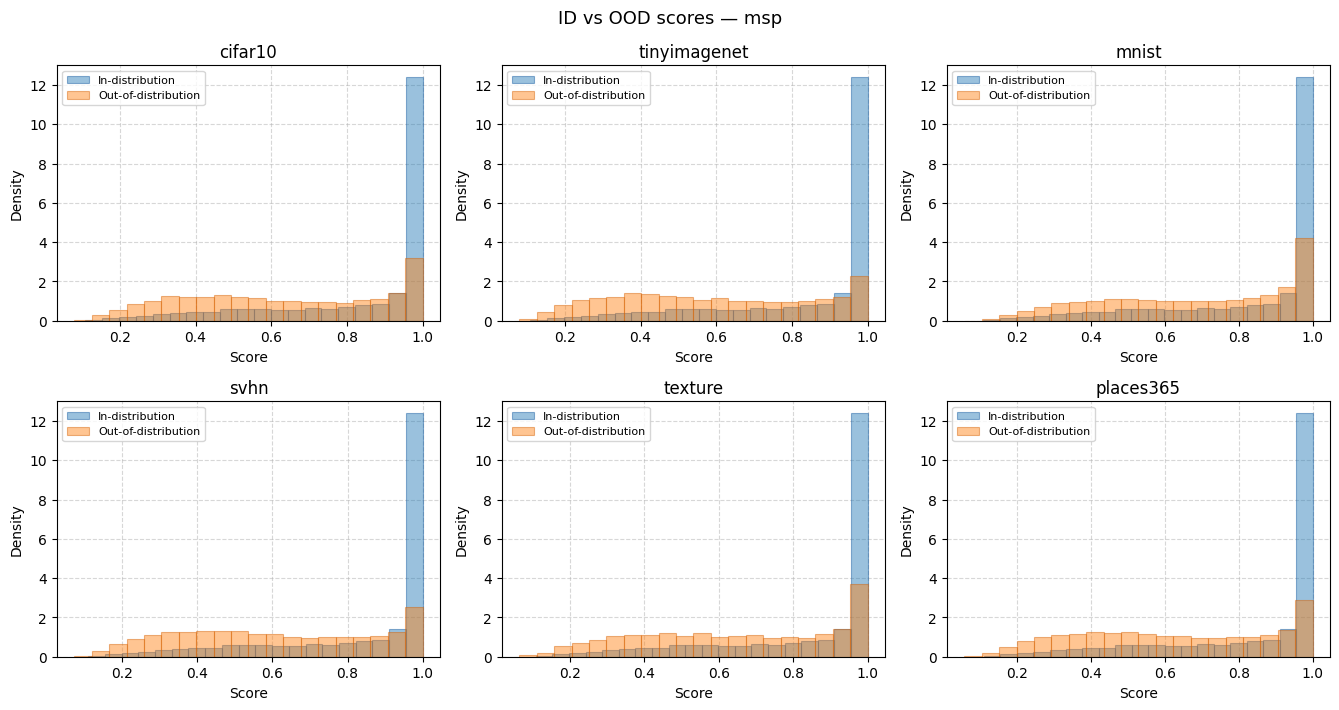

In [7]:
plot_ood_histograms(routine, "msp")

In [8]:
#NECO as criterion
routine = ClassificationRoutine(
    num_classes=datamodule.num_classes,
    eval_ood=True,
    model=net,
    loss=nn.CrossEntropyLoss(),
    eval_shift=True,
    ood_criterion="neco",
    log_plots=True,
)

# Perform testing using the defined routine and datamodule.
results = trainer.test(model=routine, datamodule=datamodule)

/home/themis/miniconda3/envs/test/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `FPR95` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Files already downloaded and verified
Setup: 100%|██████████| 250/250 [00:09<00:00, 25.59it/s]
Starting hyperparameter search for selected OOD eval method...
Tried {'neco_dim': 50} → VAL AUROC = 0.8217
Tried {'neco_dim': 100} → VAL AUROC = 0.8219
Tried {'neco_dim': 200} → VAL AUROC = 0.8212
✓ Selected {'neco_dim': 100} with AUROC=0.8219
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/themis/miniconda3/envs/test/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.


Testing DataLoader 9: 100%|██████████| 950/950 [00:33<00:00, 28.77it/s]


┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃      Classification       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     Acc      │          74.750%          │
│    Brier     │          0.36506          │
│   Entropy    │          0.53935          │
│     NLL      │          1.02712          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃        Calibration        ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     ECE      │          9.477%           │
│     aECE     │          9.477%           │
└──────────────┴───────────────────────────┘
                           OOD Results                           
┏━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┓
┃     Dataset      │    AUROC     │    FPR95     │     AUPR     ┃
┠──────────────────┼──────────────┼──────────────┼──────────────┨
┃     cifar10      │   77.495%    │   64.820%    │   73.280%    ┃
┃   tinyimagenet   │   81.027%    │   56.550%    │   68.966%    ┃
┃ NearOOD Average  │   79.261%    │   60.685%    │   71.123%    ┃
┃      mnist       │   79.707%    │   54.730%    │   95.142%    ┃
┃       svhn       │   81.344%    │   52.300%    │   89.184%    ┃
┃     texture      │   77.074%    │   66.660%    │   61.481%    ┃
┃    places365     │   79.140%    │   58.820%    │   90.721%    ┃
┃  FarOOD Average  │   79.316%    │   58.127%    │   84.132%    ┃
┗━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┛
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃ Selective Classification  ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    AUGRC     │          5.702%           │
│     AURC     │          7.389%           │
│  Cov@5Risk   │          53.320%          │
│  Risk@80Cov  │          15.050%          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃  Distribution Shift lvl1  ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    AUGRC     │          10.956%          │
│     AURC     │          15.212%          │
│     Acc      │          62.207%          │
│    Brier     │          0.54208          │
│  Cov@5Risk   │           nan%            │
│     ECE      │          15.674%          │
│     NLL      │          1.75462          │
│  Risk@80Cov  │          27.999%          │
│     aECE     │          15.668%          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃        Complexity         ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    flops     │         222.19 G          │
│    params    │          11.22 M          │
└──────────────┴───────────────────────────┘

Saved figures/ood_tutorial/hist_grid_neco.png


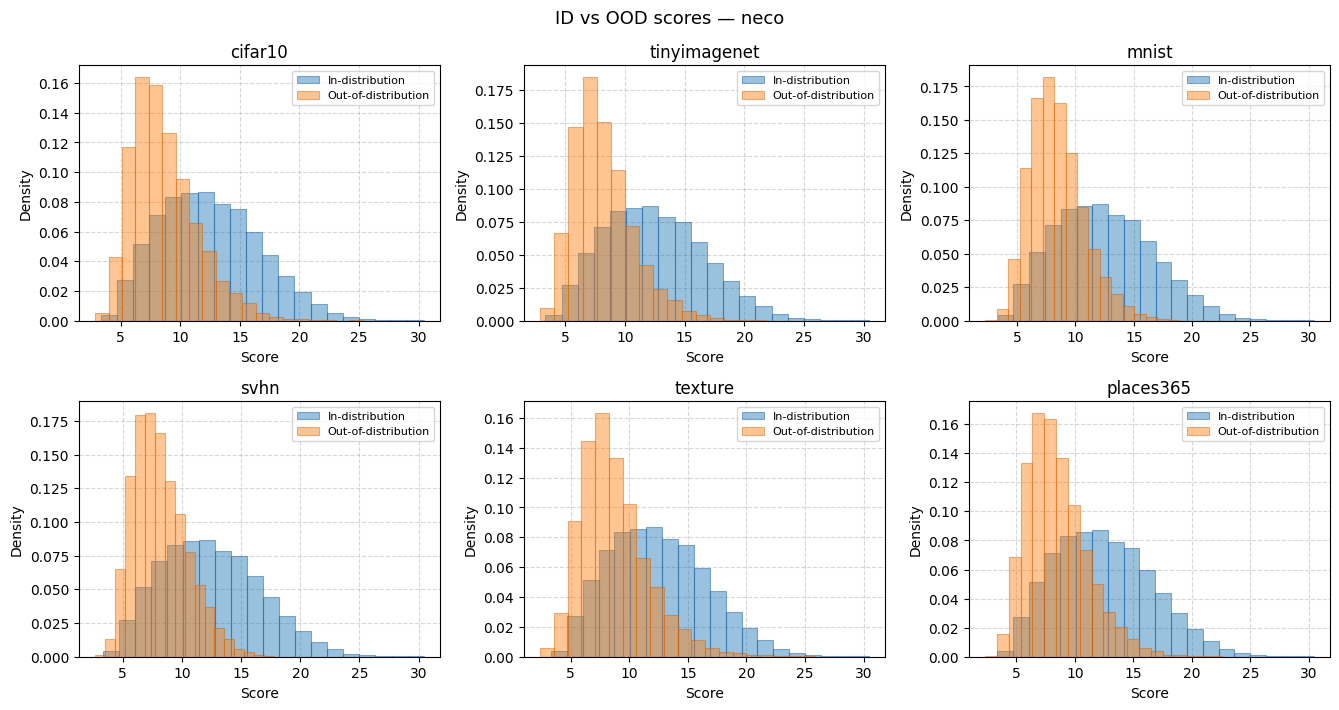

In [9]:
plot_ood_histograms(routine, "neco")

In [10]:
#SCALE as criterion
routine = ClassificationRoutine(
    num_classes=datamodule.num_classes,
    eval_ood=True,
    model=net,
    loss=nn.CrossEntropyLoss(),
    eval_shift=True,
    ood_criterion="scale",
    log_plots=True,
)
results = trainer.test(model=routine, datamodule=datamodule)

/home/themis/miniconda3/envs/test/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `FPR95` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Files already downloaded and verified
Starting hyperparameter search for selected OOD eval method...
Tried {'percentile_list': 65} → VAL AUROC = 0.8147
Tried {'percentile_list': 70} → VAL AUROC = 0.8093
Tried {'percentile_list': 75} → VAL AUROC = 0.7982
Tried {'percentile_list': 80} → VAL AUROC = 0.7709
Tried {'percentile_list': 85} → VAL AUROC = 0.6975
Tried {'percentile_list': 90} → VAL AUROC = 0.5011
Tried {'percentile_list': 95} → VAL AUROC = 0.3068
✓ Selected {'percentile_list': 65} with AUROC=0.8147
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/themis/miniconda3/envs/test/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers whi

Testing DataLoader 9: 100%|██████████| 950/950 [00:18<00:00, 51.07it/s]


┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃      Classification       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     Acc      │          74.750%          │
│    Brier     │          0.36506          │
│   Entropy    │          0.53935          │
│     NLL      │          1.02712          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃        Calibration        ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     ECE      │          9.477%           │
│     aECE     │          9.477%           │
└──────────────┴───────────────────────────┘
                           OOD Results                           
┏━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┓
┃     Dataset      │    AUROC     │    FPR95     │     AUPR     ┃
┠──────────────────┼──────────────┼──────────────┼──────────────┨
┃     cifar10      │   77.175%    │   65.470%    │   73.081%    ┃
┃   tinyimagenet   │   80.501%    │   59.340%    │   68.514%    ┃
┃ NearOOD Average  │   78.838%    │   62.405%    │   70.797%    ┃
┃      mnist       │   79.268%    │   54.660%    │   95.028%    ┃
┃       svhn       │   82.957%    │   48.600%    │   90.278%    ┃
┃     texture      │   79.743%    │   63.830%    │   65.842%    ┃
┃    places365     │   80.018%    │   58.760%    │   91.244%    ┃
┃  FarOOD Average  │   80.497%    │   56.463%    │   85.598%    ┃
┗━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┛
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃ Selective Classification  ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    AUGRC     │          5.702%           │
│     AURC     │          7.389%           │
│  Cov@5Risk   │          53.320%          │
│  Risk@80Cov  │          15.050%          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃  Distribution Shift lvl1  ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    AUGRC     │          10.956%          │
│     AURC     │          15.212%          │
│     Acc      │          62.207%          │
│    Brier     │          0.54208          │
│  Cov@5Risk   │           nan%            │
│     ECE      │          15.674%          │
│     NLL      │          1.75462          │
│  Risk@80Cov  │          27.999%          │
│     aECE     │          15.668%          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃        Complexity         ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    flops     │         222.19 G          │
│    params    │          11.22 M          │
└──────────────┴───────────────────────────┘

Saved figures/ood_tutorial/hist_grid_scale.png


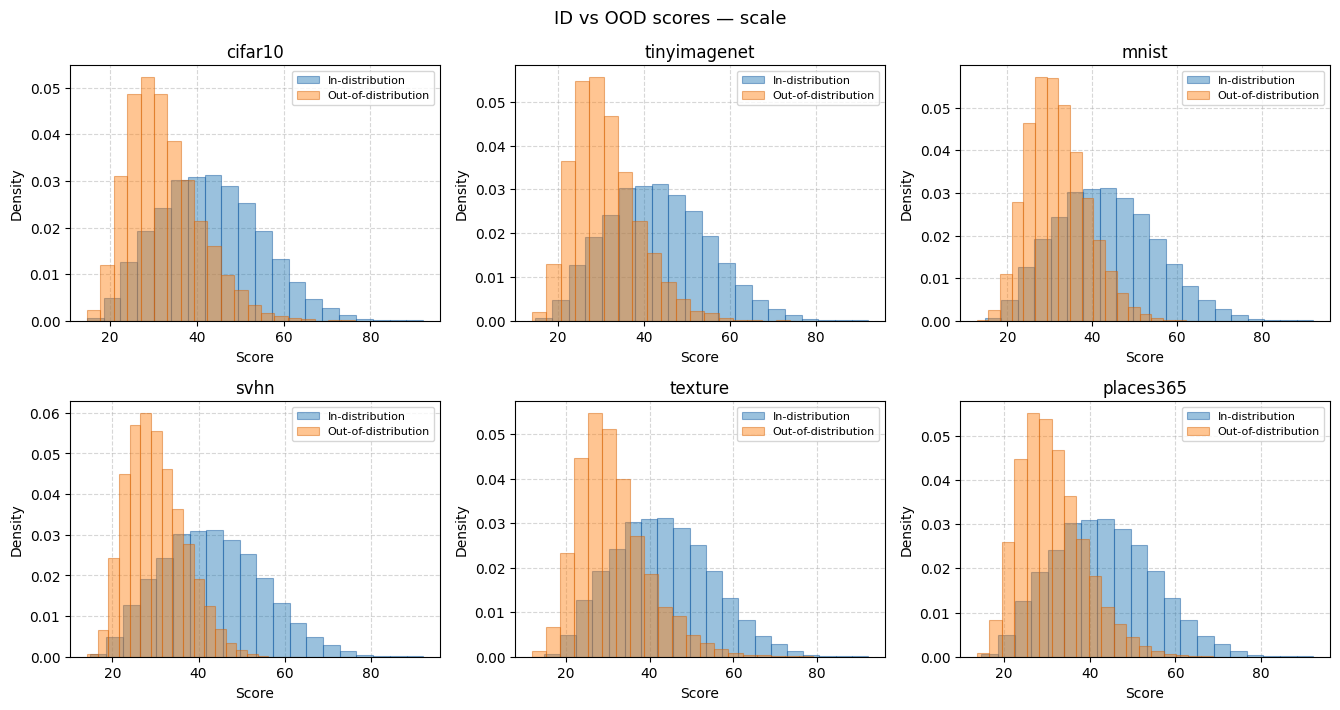

In [11]:
plot_ood_histograms(routine, "scale")

Here, we show the various test metrics along with the ood eval metrics, auroc,aupr and fpr95 on Near and far ood datasets defined per defualt according to OpenOOD splits (link to library)


## 5. Defining custom ood datasets
If you don't want to use the openood datasets or dataset splits, you can pass your own datasets in a list to near_ood_datasets or far_ood_datasets datamodule arguments
and use them for ood evaluation but make sure they inherit from the
Dataset class from torch.utils.data, below is an example of such a case.


In [12]:
from torchvision.datasets import CIFAR10, MNIST
from torchvision.transforms import v2

test_transform = v2.Compose(
    [
        v2.ToImage(),
        v2.Resize(32),
        v2.CenterCrop(32),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.5071, 0.4867, 0.4408)),
    ]
)

custom_dataset1 = CIFAR10(root=root, train=False, download=True, transform=test_transform)
custom_dataset2 = MNIST(root=root, train=False, download=True, transform=test_transform)

datamodule = CIFAR100DataModule(
    root=root,
    batch_size=200,
    eval_ood=True,
    eval_shift=True,
    near_ood_datasets=[custom_dataset1],
    far_ood_datasets=[custom_dataset2],
)

# Perform testing using the CUSTOM defined ood datasets.
results = trainer.test(model=routine, datamodule=datamodule)

Files already downloaded and verified
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/themis/miniconda3/envs/test/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.


Testing DataLoader 5: 100%|██████████| 950/950 [00:18<00:00, 50.33it/s]


┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃      Classification       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     Acc      │          74.750%          │
│    Brier     │          0.36506          │
│   Entropy    │          0.53935          │
│     NLL      │          1.02712          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃        Calibration        ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     ECE      │          9.477%           │
│     aECE     │          9.477%           │
└──────────────┴───────────────────────────┘
                           OOD Results                           
┏━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┓
┃     Dataset      │    AUROC     │    FPR95     │     AUPR     ┃
┠──────────────────┼──────────────┼──────────────┼──────────────┨
┃     cifar10      │   80.041%    │   58.080%    │   75.674%    ┃
┃ NearOOD Average  │   80.041%    │   58.080%    │   75.674%    ┃
┃      mnist       │   59.172%    │   86.580%    │   52.651%    ┃
┃  FarOOD Average  │   59.172%    │   86.580%    │   52.651%    ┃
┗━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┛
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃ Selective Classification  ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    AUGRC     │          5.702%           │
│     AURC     │          7.389%           │
│  Cov@5Risk   │          53.320%          │
│  Risk@80Cov  │          15.050%          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃  Distribution Shift lvl1  ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    AUGRC     │          10.956%          │
│     AURC     │          15.212%          │
│     Acc      │          62.207%          │
│    Brier     │          0.54208          │
│  Cov@5Risk   │           nan%            │
│     ECE      │          15.674%          │
│     NLL      │          1.75462          │
│  Risk@80Cov  │          27.999%          │
│     aECE     │          15.668%          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃        Complexity         ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    flops     │         222.19 G          │
│    params    │          11.22 M          │
└──────────────┴───────────────────────────┘

References
- **OpenOOD:** Jingyang Zhang & al. [Neurips 2025](https://arxiv.org/pdf/2306.09301) |. OpenOOD v1.5: Enhanced Benchmark for Out-of-Distribution Detection.
